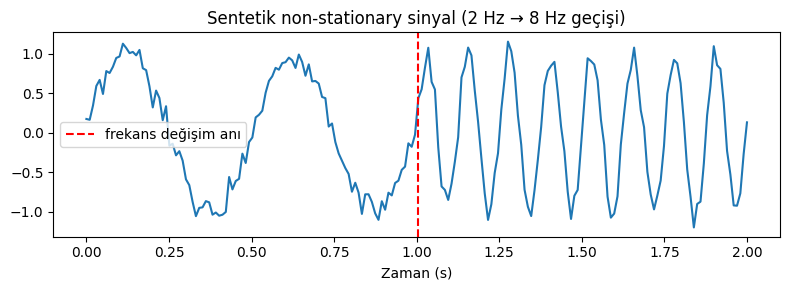

In [ ]:
!pip install vmdpy -q
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD

np.random.seed(0)
fs = 100          # örnekleme frekansı (Hz)
T_dur = 2         # saniye
t = np.linspace(0, T_dur, fs*T_dur)

# Zamanla değişen (non-stationary) sentetik EEG-benzeri sinyal:
# ilk yarıda 2 Hz baskın, ikinci yarıda 8 Hz baskın + gürültü
half = len(t)//2
signal = np.concatenate([
    np.sin(2*np.pi*2*t[:half]),
    np.sin(2*np.pi*8*t[half:])
]) + 0.1*np.random.randn(len(t))

plt.figure(figsize=(8,3))
plt.plot(t, signal)
plt.axvline(t[half], color='red', linestyle='--', label='frekans değişim anı')
plt.title("Sentetik non-stationary sinyal (2 Hz → 8 Hz geçişi)")
plt.xlabel("Zaman (s)"); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
alpha_paper = 2000      # makaledeki penalty parametresi (Section 3.2)
tau = 0.0                # noise-tolerance (dual ascent zaman adımı), 0 = kesin kısıt
K = 8                    # makaledeki optimal mod sayısı (Section 3.3.3)
DC = 0                   # ilk modun DC (sıfır frekans) bileşeni olup olmayacağı
init = 1                 # merkez frekansların başlangıç dağılımı
tol = 1e-6               # makaledeki yakınsama eşiği (Section 3.2)

u, u_hat, omega = VMD(signal, alpha_paper, tau, K, DC, init, tol)

print("Modların shape'i (K, T):", u.shape)
print("Tahmini merkez frekanslar (normalize, 0-0.5 arası):", np.round(omega[-1], 4))

Modların shape'i (K, T): (8, 200)
Tahmini merkez frekanslar (normalize, 0-0.5 arası): [0.0188 0.0747 0.0836 0.0978 0.2573 0.3226 0.3886 0.4248]


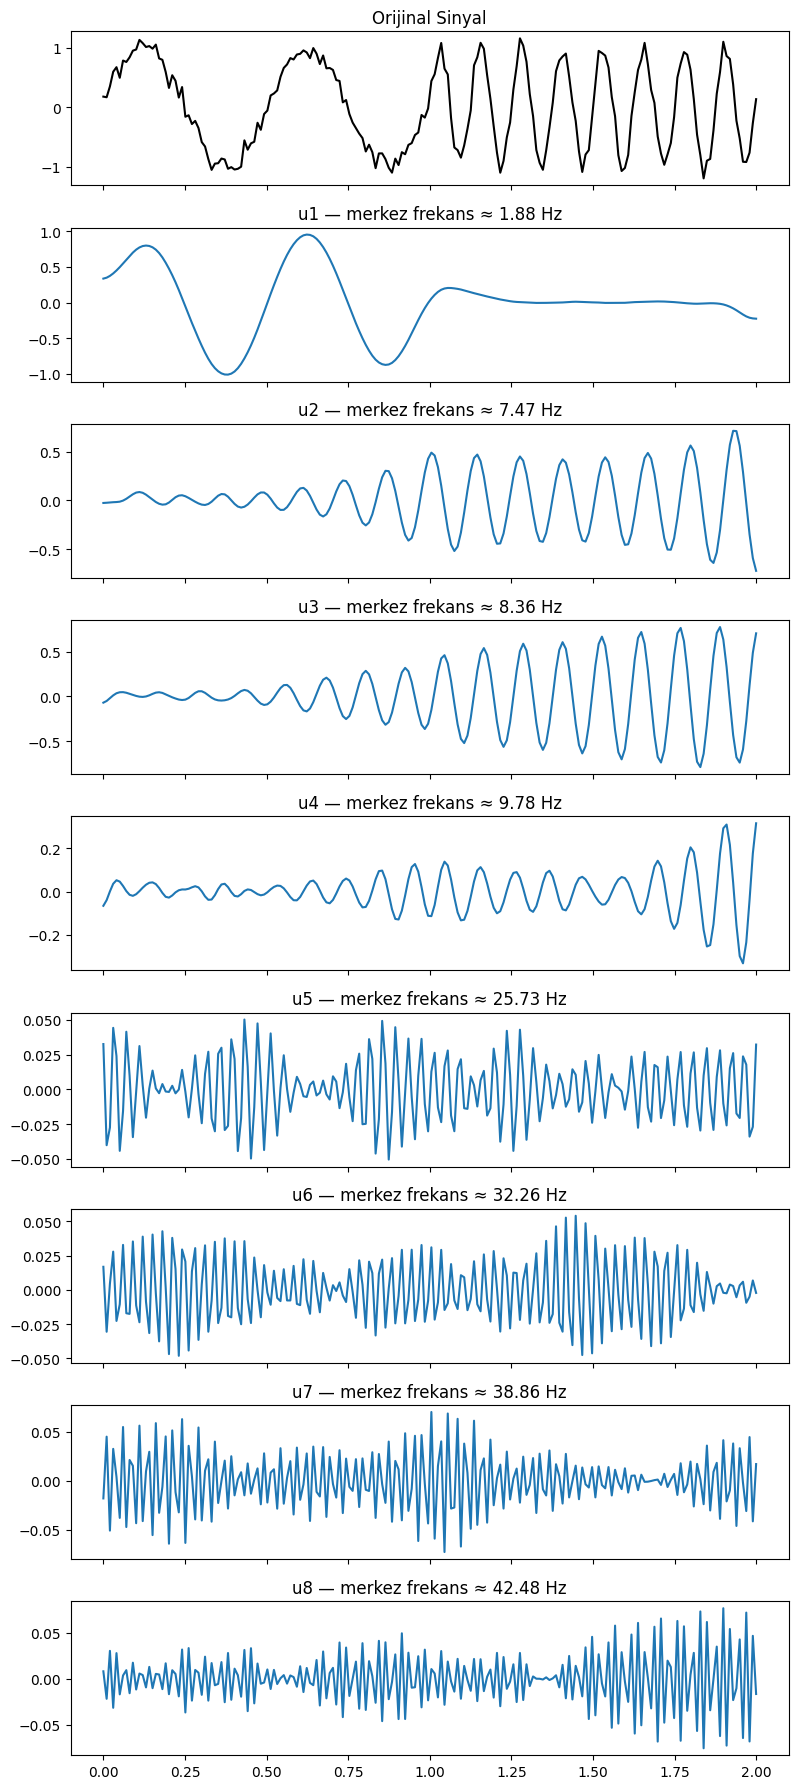

In [ ]:
fig, axes = plt.subplots(K+1, 1, figsize=(8, 2*(K+1)), sharex=True)
axes[0].plot(t, signal, color='black')
axes[0].set_title("Orijinal Sinyal")

for k in range(K):
    axes[k+1].plot(t, u[k], color='tab:blue')
    freq_hz = omega[-1][k]*fs
    axes[k+1].set_title(f"u{k+1} — merkez frekans ≈ {freq_hz:.2f} Hz")

plt.tight_layout()
plt.show()

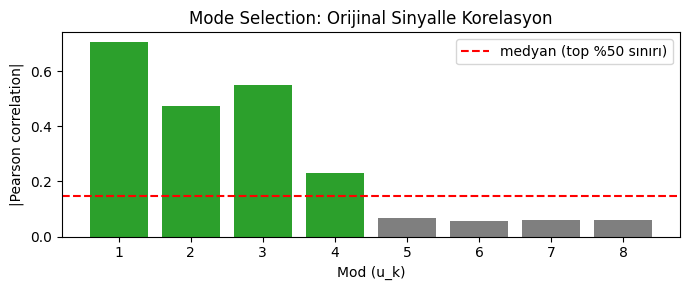

Seçilen (K') modlar: [1 2 3 4]


In [ ]:
correlations = np.array([np.corrcoef(signal, u[k])[0,1] for k in range(K)])
abs_corr = np.abs(correlations)
median_corr = np.median(abs_corr)
selected = abs_corr >= median_corr   # top %50

fig, ax = plt.subplots(figsize=(7,3))
colors = ['tab:green' if s else 'tab:gray' for s in selected]
ax.bar(range(1,K+1), abs_corr, color=colors)
ax.axhline(median_corr, color='red', linestyle='--', label='medyan (top %50 sınırı)')
ax.set_xlabel("Mod (u_k)"); ax.set_ylabel("|Pearson correlation|")
ax.set_title("Mode Selection: Orijinal Sinyalle Korelasyon")
ax.legend()
plt.tight_layout(); plt.show()

print("Seçilen (K') modlar:", np.where(selected)[0]+1)

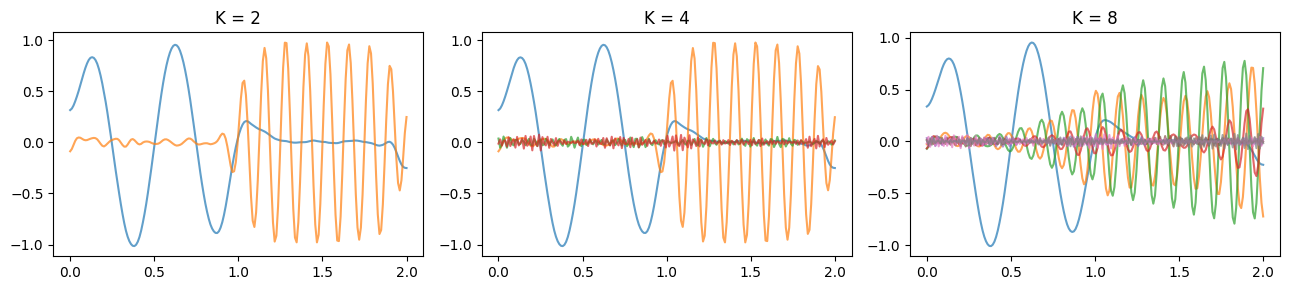

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13,3))
for ax, K_test in zip(axes, [2, 4, 8]):
    u_test, _, omega_test = VMD(signal, alpha_paper, tau, K_test, DC, init, tol)
    for k in range(K_test):
        ax.plot(t, u_test[k], alpha=0.7)
    ax.set_title(f"K = {K_test}")
plt.tight_layout(); plt.show()

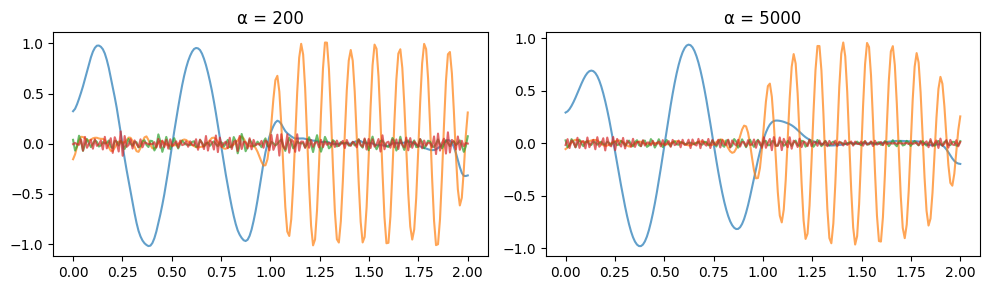

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,3))
for ax, alpha_test in zip(axes, [200, 5000]):
    u_test, _, omega_test = VMD(signal, alpha_test, tau, 4, DC, init, tol)
    for k in range(4):
        ax.plot(t, u_test[k], alpha=0.7)
    ax.set_title(f"α = {alpha_test}")
plt.tight_layout(); plt.show()